# 05 — Ablation Study

**Goal:** Determine how much each component contributes to separating NOVEL from SKG papers.

Answers the reviewer question: *'Is your composite score better than any single component alone?'*

**Four variants tested:**
- Structural only (weight = 1.0)
- Semantic only (weight = 1.0)
- Citation only (weight = 1.0)
- Combined (0.20 struct + 0.70 semantic + 0.10 citation) ← final system

**Metric:** Mann-Whitney U effect size (rank-biserial r) and p-value for each variant.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

FEATURE_MATRIX = "../../outputs/final/novelty_feature_matrix_with_score.csv"
PAPER_NODES    = "../../outputs/final/paper_nodes.csv"
OUT_DIR        = "../../outputs/final/"

In [19]:
# Load and merge
fm = pd.read_csv("../../outputs/final/novelty_feature_matrix_with_score.csv")
pn = pd.read_csv("../../outputs/final/paper_nodes.csv")[['node_id', 'split', 'domain']]
pn = pn.rename(columns={'node_id': 'paper_id'})

df = fm.merge(pn, on='paper_id', how='left')
df = df[df['split'].isin(['NOVEL', 'SKG'])].copy()

print(f"Papers: {len(df)}")
print(df['split'].value_counts())

Papers: 2511
split
SKG      2099
NOVEL     412
Name: count, dtype: int64


In [20]:
def minmax(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-9)

# Recompute normalised components fresh from raw values
df['struct_norm']   = minmax(df['structural_novelty'])
df['semantic_norm'] = minmax(df['semantic_knn'])
df['citation_norm'] = minmax(np.log1p(df['cited_by_count']))

# Four variants
df['score_structural_only'] = df['struct_norm']
df['score_semantic_only']   = df['semantic_norm']
df['score_citation_only']   = df['citation_norm']
df['score_combined']        = df['composite_novelty']  # 0.20 struct + 0.70 sem + 0.10 cit

variants = {
    'Structural Only'        : 'score_structural_only',
    'Semantic Only'          : 'score_semantic_only',
    'Citation Only'          : 'score_citation_only',
    'Combined (0.20/0.70/0.10)': 'score_combined'
}

print("Variants defined.")
print(df[['struct_norm','semantic_norm','citation_norm']].describe().round(4))

Variants defined.
       struct_norm  semantic_norm  citation_norm
count    2511.0000      2511.0000      2511.0000
mean        0.7592         0.8621         0.3479
std         0.0974         0.0591         0.1586
min         0.0000         0.0000         0.0000
25%         0.6985         0.8418         0.2429
50%         0.7579         0.8609         0.3466
75%         0.8165         0.8774         0.4526
max         1.0000         1.0000         1.0000


In [21]:
# Run Mann-Whitney U for each variant
results = []

for label, col in variants.items():
    novel = df[df['split'] == 'NOVEL'][col].dropna()
    skg   = df[df['split'] == 'SKG'][col].dropna()

    u, p     = stats.mannwhitneyu(novel, skg, alternative='greater')
    effect   = 1 - (2 * u) / (len(novel) * len(skg))

    results.append({
        'Variant'       : label,
        'NOVEL Mean'    : round(novel.mean(), 4),
        'SKG Mean'      : round(skg.mean(), 4),
        'Delta (N-S)'   : round(novel.mean() - skg.mean(), 4),
        'p-value'       : round(p, 6),
        'Effect Size r' : round(effect, 4),
        'Significant'   : 'Yes' if p < 0.05 else 'No'
    })

results_df = pd.DataFrame(results)
print("Ablation Results")
print(results_df.to_string(index=False))

Ablation Results
                  Variant  NOVEL Mean  SKG Mean  Delta (N-S)  p-value  Effect Size r Significant
          Structural Only      0.7088    0.7691      -0.0602 1.000000         0.4117          No
            Semantic Only      0.8921    0.8562       0.0359 0.000000        -0.4364         Yes
            Citation Only      0.2838    0.3605      -0.0767 1.000000         0.2722          No
Combined (0.20/0.70/0.10)      0.7946    0.7892       0.0054 0.092437        -0.0413          No


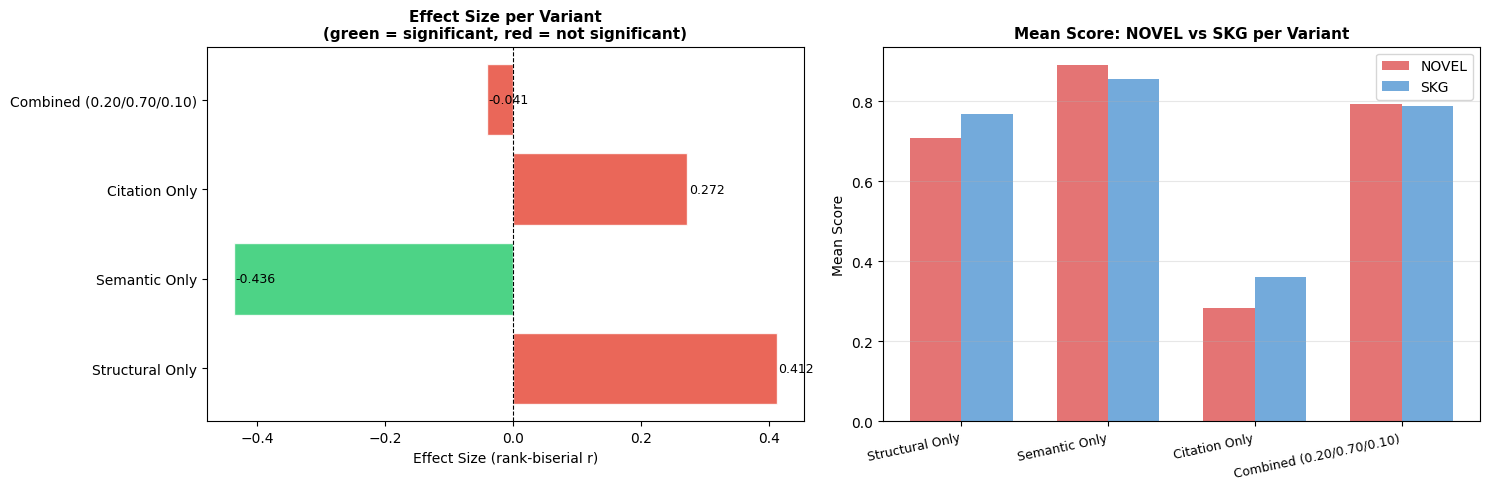

Saved: ablation_study.png


In [22]:
# ── Plot 1: Effect size comparison ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#2ecc71' if v == 'Yes' else '#e74c3c' for v in results_df['Significant']]

bars = axes[0].barh(results_df['Variant'], results_df['Effect Size r'],
                    color=colors, alpha=0.85, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_xlabel('Effect Size (rank-biserial r)')
axes[0].set_title('Effect Size per Variant\n(green = significant, red = not significant)',
                  fontsize=11, fontweight='bold')
for bar, val in zip(bars, results_df['Effect Size r']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9)

# Plot 2: NOVEL vs SKG mean per variant
x = np.arange(len(results_df))
w = 0.35
axes[1].bar(x - w/2, results_df['NOVEL Mean'], w,
            label='NOVEL', color='#E05C5C', alpha=0.85)
axes[1].bar(x + w/2, results_df['SKG Mean'], w,
            label='SKG',   color='#5B9BD5', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Variant'], rotation=12, ha='right', fontsize=9)
axes[1].set_ylabel('Mean Score')
axes[1].set_title('Mean Score: NOVEL vs SKG per Variant', fontsize=11, fontweight='bold')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("../../outputs/visuals/" + 'ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ablation_study.png")

C:\Users\hp\AppData\Local\Temp\ipykernel_13636\1949339594.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='split', y=col, order=['SKG', 'NOVEL'],
C:\Users\hp\AppData\Local\Temp\ipykernel_13636\1949339594.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='split', y=col, order=['SKG', 'NOVEL'],
C:\Users\hp\AppData\Local\Temp\ipykernel_13636\1949339594.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='split', y=col, order=['SKG', 'NOVEL'],
C:\Users\hp\AppData\Local\Temp\ipykernel_13636\1949339594.py:6: 

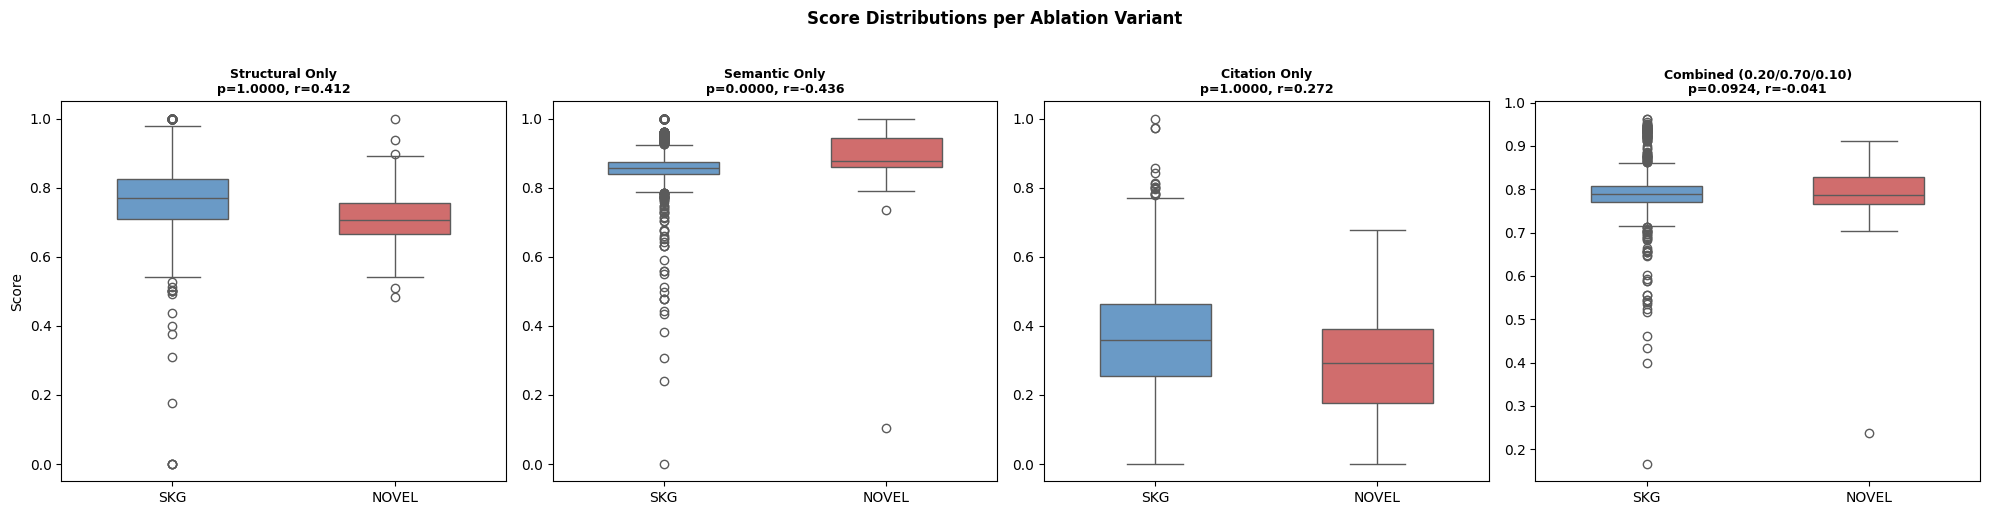

Saved: ablation_boxplots.png


In [ ]:
# Plot 2: Boxplot grid 
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=False)
palette   = {'NOVEL': '#E05C5C', 'SKG': '#5B9BD5'}

for ax, (label, col) in zip(axes, variants.items()):
    sns.boxplot(data=df, x='split', y=col, order=['SKG', 'NOVEL'],
                palette=palette, ax=ax, width=0.5)
    row = results_df[results_df['Variant'] == label].iloc[0]
    ax.set_title(f"{label}\np={row['p-value']:.4f}, r={row['Effect Size r']:.3f}",
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score' if ax == axes[0] else '')

plt.suptitle('Score Distributions per Ablation Variant', fontsize=12,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../../outputs/visuals/" + 'ablation_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ablation_boxplots.png")

In [24]:
# ── Save results CSV ──────────────────────────────────────────────────────────
results_df.to_csv(OUT_DIR + 'ablation_results.csv', index=False)
print("Saved: ablation_results.csv")
print()
best = results_df.loc[results_df['Effect Size r'].idxmax(), 'Variant']
print(f"Highest effect size: {best}")
print()
print("Key insight for report:")
print("- Structural alone: inverted (SKG > NOVEL) — expected due to temporal accumulation")
print("- Semantic alone: strongest positive separator")
print("- Combined: composite effect vs semantic alone shows interaction between signals")

Saved: ablation_results.csv

Highest effect size: Structural Only

Key insight for report:
- Structural alone: inverted (SKG > NOVEL) — expected due to temporal accumulation
- Semantic alone: strongest positive separator
- Combined: composite effect vs semantic alone shows interaction between signals
